IMPORTS + CONFIG

In [26]:
import ast
import json
import os
import time
from collections import Counter, defaultdict
from pathlib import Path

import nbformat
import requests
from secret import GITHUB_TOKEN
from experiments import largest_data_transformations
import numpy as np


In [29]:

# -----------------------------------
# GITHUB CONFIG
# -----------------------------------


HEADERS = {
    "Authorization": f"Bearer {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
}

# Better than generic ipynb search
#QUERYS = 'extension:ipynb train_test_split OR StandardScaler'#'extension:ipynb "import pandas"'
QUERYS = [
    'extension:ipynb train_test_split',
    'extension:ipynb sklearn.preprocessing',
    'extension:ipynb LabelEncoder',
    'extension:ipynb OneHotEncoder',
    'extension:ipynb pandas.read_csv',
    'extension:ipynb RandomForestClassifier',
    'extension:ipynb XGBClassifier',
    'extension:ipynb feature engineering',
    'extension:ipynb data cleaning',
    'extension:ipynb data cleansing',
    'extension:ipynb date prep',
    'extension:ipynb exploration',
    'extension:ipynb EDA'
    ]
MAX_NOTEBOOKS_PER_QUERY = 600

GITHUB_NOTEBOOKS = 'notebooks_new'
KAGGLE_NOTEBOOKS = 'kaggle_notebooks_new'

SAVE_DIR = Path(GITHUB_NOTEBOOKS)#Path("notebooks_sanity_test")
SAVE_DIR.mkdir(exist_ok=True)

eps = 1e-10



In [3]:
transformations = list(largest_data_transformations.keys())

EXTRACT GITHUB DATA

In [4]:
# -----------------------------------
# SEARCH GITHUB NOTEBOOKS
# -----------------------------------

def search_notebooks(query, page=1):

    url = "https://api.github.com/search/code"

    params = {
        "q": query,
        "per_page": 100,
        "page": page,
    }

    r = requests.get(
        url,
        headers=HEADERS,
        params=params,
    )
    print(r.status_code)
    print(r.text)
    if r.status_code != 200:

        print("GitHub API ERROR")
        print(r.text)

        return []

    data = r.json()

    return data.get("items", [])

# -----------------------------------
# DOWNLOAD NOTEBOOK
# -----------------------------------

def github_raw_url(html_url):

    raw = html_url.replace(
        "github.com",
        "raw.githubusercontent.com"
    )

    raw = raw.replace("/blob/", "/")

    return raw


def download_notebook(item):

    raw_url = github_raw_url(
        item["html_url"]
    )

    try:

        r = requests.get(raw_url)

        if r.status_code != 200:

            print("FAILED:", raw_url)
            return False

        # verify notebook JSON

        try:

            notebook_json = r.json()

        except Exception:

            print(
                "NOT JSON:",
                raw_url
            )

            return False

        # notebook sanity check

        if "cells" not in notebook_json:

            print(
                "NO CELLS:",
                raw_url
            )

            return False

        repo_name = (
            item["repository"]["full_name"]
            .replace("/", "__")
        )

        filename = item["name"]

        out_path = (
            SAVE_DIR /
            f"{repo_name}__{filename}"
        )

        with open(
            out_path,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                notebook_json,
                f,
            )

        return True

    except Exception as e:

        print("ERROR:", e)

        return False

CRAWL

In [5]:
# -----------------------------------
# CRAWL NOTEBOOKS
# -----------------------------------

def crawl_notebooks():

    downloaded = 0
    page = 1
    downloaded_notebooks = set()
    for query in QUERYS:
        print("\n*************\nQUERY:", query)
        while downloaded < MAX_NOTEBOOKS_PER_QUERY:

            print(f"\nPAGE {page}")

            items = search_notebooks(query, page)

            if not items:
                print("No more results")
                break

            for item in items:
                repo_name = (
                    item["repository"]["full_name"]
                    .replace("/", "__")
                )
                filename = item["name"]
                notebook_name = f"{repo_name}__{filename}"
                if notebook_name in downloaded_notebooks:
                    print("seen this notebook!")
                    continue

                downloaded_notebooks.add(notebook_name)
                success = download_notebook(item)

                if success:

                    downloaded += 1

                    print(
                        f"Downloaded {downloaded}"
                    )

                if downloaded >= MAX_NOTEBOOKS_PER_QUERY:
                    break

                # avoid rate limits
                time.sleep(0.2)

            page += 1

        downloaded = 0
        page = 1

    print("\nDONE")

In [6]:
# -----------------------------------
# LOAD NOTEBOOK CODE CELLS
# -----------------------------------

def extract_code_cells(notebook_path):

    try:

        nb = nbformat.read(
            notebook_path,
            as_version=4,
        )

        cells = [

            c["source"]

            for c in nb.cells

            if c.cell_type == "code"
        ]

        return cells

    except Exception as e:

        print(f"FAILED: {notebook_path}")
        print(e)

        return []

SEMANTIC RULE ENGINE

In [7]:
# -----------------------------------
# SEMANTIC RULE ENGINE
# -----------------------------------

class SemanticPreprocessingVisitor(ast.NodeVisitor):

    def __init__(self):

        self.transforms = []

        # ---------------------------------
        # symbolic quartile tracking
        # ---------------------------------

        self.last_q1 = None
        self.last_q3 = None

    # -----------------------------------
    # HELPERS
    # -----------------------------------

    def resolve_constant(self, node):

        if isinstance(node, ast.Constant):
            return node.value

        return None

    def get_argument(
        self,
        node,
        kw_name,
        position,
    ):

        # keyword arg

        for kw in node.keywords:

            if kw.arg == kw_name:

                return self.resolve_constant(
                    kw.value
                )

        # positional arg

        if len(node.args) > position:

            return self.resolve_constant(
                node.args[position]
            )

        return None

    # -----------------------------------
    # FUNCTION CALLS
    # -----------------------------------

    def visit_Call(self, node):

        # ---------------------------------
        # attribute calls
        # ---------------------------------

        if isinstance(node.func, ast.Attribute):

            attr = node.func.attr.lower()

            # qcut

            if attr == "qcut":

                q_value = self.get_argument(
                    node=node,
                    kw_name="q",
                    position=1,
                )

                if q_value in [2, 5, 10]:

                    self.transforms.append(
                        f"bin_equal_frequency_{q_value}"
                    )

            # cut

            elif attr == "cut":

                bins_value = self.get_argument(
                    node=node,
                    kw_name="bins",
                    position=1,
                )

                if bins_value in [2, 5, 10]:

                    self.transforms.append(
                        f"bin_equal_width_{bins_value}"
                    )

            # winsorize

            elif attr == "winsorize":

                self.transforms.append(
                    "winsorize"
                )

            # explicit iqr function

            elif attr == "iqr":

                self.transforms.append(
                    "IQR"
                )

            elif attr == "zscore":
                self.transforms.append(
                    "zscore"
                )
            # ---------------------------------
            # deduplication
            # ---------------------------------

            elif attr == "drop_duplicates":
                self.transforms.append(
                    "drop_duplicates"
                )

        # ---------------------------------
        # direct function calls
        # ---------------------------------

        elif isinstance(node.func, ast.Name):

            func_name = node.func.id.lower()

            # IsolationForest

            if func_name == "isolationforest":

                self.transforms.append(
                    "isolationForest"
                )

            # winsorize

            elif func_name == "winsorize":

                self.transforms.append(
                    "winsorize"
                )

            # IQR

            elif func_name == "iqr":

                self.transforms.append(
                    "IQR"
                )

            # MinMaxScaler

            elif func_name in [
                "minmaxscaler",
                "minmax_scale",
            ]:

                self.transforms.append(
                    "norm_min_max"
                )

            elif func_name == "zscore":
                self.transforms.append(
                    "zscore"
                )

        self.generic_visit(node)

    # -----------------------------------
    # ASSIGNMENTS
    # -----------------------------------

    def visit_Assign(self, node):

        # only simple assignments

        if len(node.targets) != 1:

            self.generic_visit(node)
            return

        target = node.targets[0]

        # ---------------------------------
        # variable assignment
        # ---------------------------------

        if isinstance(target, ast.Name):

            var_name = target.id

            # ---------------------------------
            # RHS is function call
            # ---------------------------------

            if isinstance(node.value, ast.Call):

                value = node.value

                # ---------------------------------
                # attribute call
                # ---------------------------------

                if isinstance(
                    value.func,
                    ast.Attribute
                ):

                    attr = value.func.attr.lower()

                    # -------------------------
                    # quantile(.25/.75)
                    # -------------------------

                    if attr == "quantile":

                        q_value = self.get_argument(
                            node=value,
                            kw_name="q",
                            position=0,
                        )

                        # Q1

                        if q_value == 0.25:

                            self.last_q1 = var_name

                        # Q3

                        elif q_value == 0.75:

                            self.last_q3 = var_name

        # ---------------------------------
        # df["col"] = np.log(...)
        # ---------------------------------

        if isinstance(target, ast.Subscript):

            value = node.value

            if isinstance(value, ast.Call):

                if isinstance(
                    value.func,
                    ast.Attribute
                ):

                    attr = value.func.attr.lower()

                    if attr in [
                        "log",
                        "log1p",
                    ]:

                        self.transforms.append(
                            "norm_log"
                        )

        self.generic_visit(node)

    # -----------------------------------
    # BINARY OPERATIONS
    # -----------------------------------

    def visit_BinOp(self, node):

        # subtraction

        if isinstance(node.op, ast.Sub):

            left = node.left
            right = node.right

            # Q3 - Q1

            if (
                isinstance(left, ast.Name)
                and isinstance(right, ast.Name)
            ):

                left_name = left.id
                right_name = right.id

                if (
                    left_name == self.last_q3
                    and right_name == self.last_q1
                ):

                    self.transforms.append(
                        "IQR"
                    )

        self.generic_visit(node)


In [8]:
# -----------------------------------
# EXTRACT TRANSFORMS FROM CODE
# -----------------------------------

def extract_transforms_from_code(code):

    try:
        tree = ast.parse(code)

        visitor = SemanticPreprocessingVisitor()

        visitor.visit(tree)
        return visitor.transforms

    except Exception:
        return []

In [9]:
# -----------------------------------
# PROCESS SINGLE NOTEBOOK
# -----------------------------------

def process_notebook(notebook_path):

    cells = extract_code_cells(
        notebook_path
    )

    notebook_transforms = []

    for cell in cells:

        transforms = (
            extract_transforms_from_code(
                cell
            )
        )

        notebook_transforms.extend(
            transforms
        )

    return notebook_transforms

In [10]:
# -----------------------------------
# ANALYZE ALL NOTEBOOKS
# -----------------------------------

def analyze_corpus(folder_names):
    if isinstance(folder_names, (str, Path)):
            folder_names = [folder_names]

    transform_counter = Counter()
    transition_counter = defaultdict(Counter)

    # 1. Collect notebook paths from ALL folders
    notebook_paths = []
    for folder in folder_names:
        save_dir = Path(folder)
        # Extend the main list with notebooks found in this specific folder
        notebook_paths.extend(list(save_dir.rglob("*.ipynb")))

    print(f"Found {len(notebook_paths)} notebooks across {len(folder_names)} folders")

    for idx, notebook_path in enumerate(notebook_paths):
        if idx % 50 == 0:
            print(f"Processing {idx}")

        transforms = process_notebook(notebook_path)
        if transforms:
            print("\n===================")
            print(notebook_path)
            print(transforms)

        # frequency counts
        transform_counter.update(transforms)

        # transitions

        for a, b in zip(transforms[:-1], transforms[1:]):
            transition_counter[a][b] += 1

    # ---------------------------------
    # transform probabilities
    # ---------------------------------

    total = sum(transform_counter.values())

    transform_probabilities = {
        t: c / total for t, c in (transform_counter.items())
    }

    # ---------------------------------
    # transition probabilities
    # ---------------------------------

    transition_probabilities = {}

    for a, next_ops in (transition_counter.items()):
        total_transitions = sum(next_ops.values())
        transition_probabilities[a] = {
            b: c / total_transitions for b, c in (next_ops.items())
        }

    return (
        transform_probabilities,
        transition_probabilities,
    )

RUN CODE

In [ ]:
crawl_notebooks()

In [ ]:
(
    transform_probabilities,
    transition_probabilities,
) = analyze_corpus(GITHUB_NOTEBOOKS)

In [ ]:
# -----------------------------------
# PRINT TRANSFORM PROBABILITIES
# -----------------------------------
print("\n=== TRANSFORM PROBABILITIES ===\n")

for transform, prob in sorted(transform_probabilities.items(), key=lambda x: x[1], reverse=True):
    print(f"{transform:30s} {prob:.4f}")

# -----------------------------------
# PRINT TRANSITION PROBABILITIES
# -----------------------------------
print("\n=== TRANSITION PROBABILITIES ===\n")

for transform_a, transitions in (transition_probabilities.items()):
    print(f"\n{transform_a} ->")

    for transform_b, prob in sorted(transitions.items(), key=lambda x: x[1], reverse=True):
        print(f"    {transform_b:30s} {prob:.4f}")

In [32]:
prob_dict = {}
for transform_op in transformations:
    prob_dict[transform_op] = transform_probabilities.get(transform_op, eps)

prob_dict['zscore_clip_3'] = transform_probabilities.get('zscore', eps)
prob_dict['zscore_filter_3'] = transform_probabilities.get('zscore', eps)
print(prob_dict)


{'bin_equal_frequency_2': 0.005063291139240506, 'bin_equal_frequency_5': 0.00590717299578059, 'bin_equal_frequency_10': 0.0033755274261603376, 'bin_equal_width_2': 1e-10, 'bin_equal_width_5': 0.010970464135021098, 'bin_equal_width_10': 0.0016877637130801688, 'norm_min_max': 0.28607594936708863, 'norm_log': 0.11476793248945148, 'zscore_clip_3': 0.030379746835443037, 'zscore_filter_3': 0.030379746835443037, 'winsorize': 0.002531645569620253, 'IQR': 0.10379746835443038, 'isolationForest': 0.016033755274261603, 'drop_duplicates': 0.41940928270042194}


In [33]:
import ast
import re
import pandas as pd


text = r"""

"""


# Find every line that looks like a Python list
list_strings = re.findall(r"^\[.*\]$", text, flags=re.MULTILINE)

# Convert them into actual Python lists
lists = [ast.literal_eval(s) for s in list_strings]

# print("Lists:")
# print(lists)

print(f"found {len(lists)} pipes")
# Average list size
avg_size = sum(len(lst) for lst in lists) / len(lists) if lists else 0

print(f"\nAverage list size: {avg_size:.2f}")

# Save to CSV (one row per list)
df = pd.DataFrame({
    "list": [str(lst) for lst in lists],
    "size": [len(lst) for lst in lists]
})
df.to_csv("pipelinesDataPrep.csv", index=False)

print("\nSaved to lists.csv")

found 708 pipes

Average list size: 1.67

Saved to lists.csv


KAGGLE


In [ ]:
(
    transform_probabilities_kaggle,
    transition_probabilities_kaggle,
) = analyze_corpus(KAGGLE_NOTEBOOKS)

In [41]:
prob_dict_kaggle = {}
for transform_op in transformations:
    prob_dict_kaggle[transform_op] = transform_probabilities_kaggle.get(transform_op, eps)

prob_dict_kaggle['zscore_clip_3'] = transform_probabilities_kaggle.get('zscore', eps)
prob_dict_kaggle['zscore_filter_3'] = transform_probabilities_kaggle.get('zscore', eps)
print(prob_dict_kaggle)


{'bin_equal_frequency_2': 1e-10, 'bin_equal_frequency_5': 0.01634877384196185, 'bin_equal_frequency_10': 0.01226158038147139, 'bin_equal_width_2': 0.0013623978201634877, 'bin_equal_width_5': 0.01226158038147139, 'bin_equal_width_10': 0.009536784741144414, 'norm_min_max': 0.28133514986376024, 'norm_log': 0.23705722070844687, 'zscore_clip_3': 0.01907356948228883, 'zscore_filter_3': 0.01907356948228883, 'winsorize': 0.004768392370572207, 'IQR': 0.0837874659400545, 'isolationForest': 0.0170299727520436, 'drop_duplicates': 0.30517711171662126}


In [42]:
for k in prob_dict.keys():
    print(f"{k} | github: {prob_dict[k]} || kaggle: {prob_dict_kaggle[k]}")

bin_equal_frequency_2 | github: 0.005063291139240506 || kaggle: 1e-10
bin_equal_frequency_5 | github: 0.00590717299578059 || kaggle: 0.01634877384196185
bin_equal_frequency_10 | github: 0.0033755274261603376 || kaggle: 0.01226158038147139
bin_equal_width_2 | github: 1e-10 || kaggle: 0.0013623978201634877
bin_equal_width_5 | github: 0.010970464135021098 || kaggle: 0.01226158038147139
bin_equal_width_10 | github: 0.0016877637130801688 || kaggle: 0.009536784741144414
norm_min_max | github: 0.28607594936708863 || kaggle: 0.28133514986376024
norm_log | github: 0.11476793248945148 || kaggle: 0.23705722070844687
zscore_clip_3 | github: 0.030379746835443037 || kaggle: 0.01907356948228883
zscore_filter_3 | github: 0.030379746835443037 || kaggle: 0.01907356948228883
winsorize | github: 0.002531645569620253 || kaggle: 0.004768392370572207
IQR | github: 0.10379746835443038 || kaggle: 0.0837874659400545
isolationForest | github: 0.016033755274261603 || kaggle: 0.0170299727520436
drop_duplicates | g

In [46]:
def get_dicts_stats(dict1, dict2):
    """Calculates correlation between two dicts with the same keys."""
    # Align values by the exact same key order
    keys = list(dict1.keys())
    x = np.array([float(dict1[k]) for k in keys])
    y = np.array([float(dict2[k]) for k in keys])
    print(f"min is {min([min(x), min(y)])}, max is {max([max(x),max(y)])}")
    # Calculate and return the Pearson correlation coefficient
    corr =  np.corrcoef(x, y)[0, 1]
    mae = np.mean(np.abs(x - y))
    rmsd = np.sqrt(np.mean((x - y) ** 2))

    print(f"corr is: {corr}\nMAE is {mae}\nRMSD is: {rmsd}")

get_dicts_stats(prob_dict, prob_dict_kaggle)

min is 1e-10, max is 0.41940928270042194
corr is: 0.928878372451449
MAE is 0.023000789995782395
RMSD is: 0.045487003777251594


TypeError: 'slope' cannot be used with non-linear scales

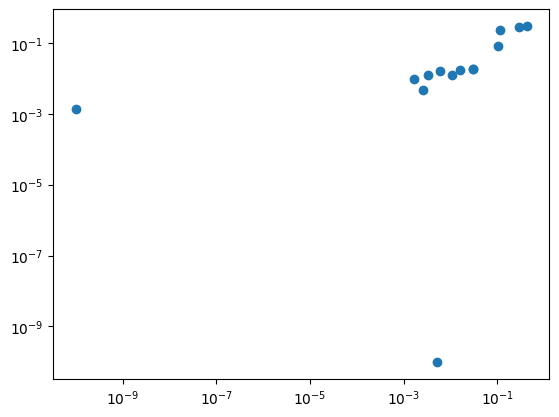

In [44]:
import matplotlib.pyplot as plt
dict1 = prob_dict
dict2 = prob_dict_kaggle
keys = list(dict1.keys())
x = np.array([float(dict1[k]) for k in keys])
y = np.array([float(dict2[k]) for k in keys])

fig,ax = plt.subplots()
ax.scatter(x,y)
ax.set_yscale('log')
ax.set_xscale('log')
ax.axline((0,0),slope=1,color='grey',dashes=(3,3))
plt.show()

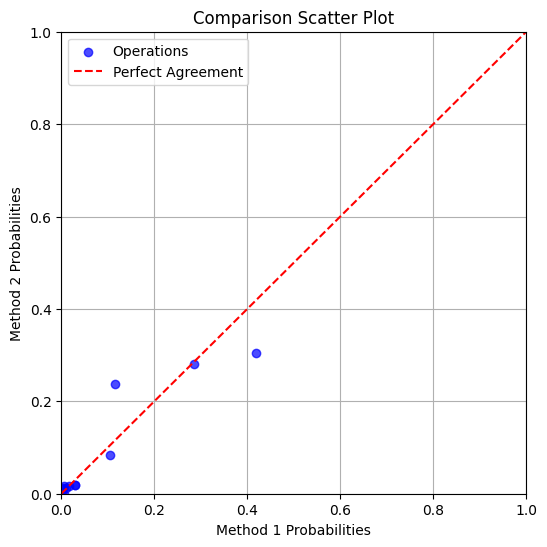

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual probability arrays)
method1 = np.array([float(dict1[k]) for k in keys])
method2 = np.array([float(dict2[k]) for k in keys])

# Create scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(method1, method2, color='blue', alpha=0.7, label='Operations')

# Add perfect agreement reference line (y = x)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Agreement')

# Formatting
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Method 1 Probabilities')
plt.ylabel('Method 2 Probabilities')
plt.title('Comparison Scatter Plot')
plt.legend()
plt.grid(True)
plt.show()


In [45]:
import ast
import re
import pandas as pd




# Find every line that looks like a Python list
text = r"""

"""
list_strings = re.findall(r"^\[.*\]$", text, flags=re.MULTILINE)

# Convert them into actual Python lists
lists = [ast.literal_eval(s) for s in list_strings]

# print("Lists:")
# print(lists)

print(f"found {len(lists)} pipes")
# Average list size
avg_size = sum(len(lst) for lst in lists) / len(lists) if lists else 0

print(f"\nAverage list size: {avg_size:.2f}")

# Save to CSV (one row per list)
df = pd.DataFrame({
    "list": [str(lst) for lst in lists],
    "size": [len(lst) for lst in lists]
})
df.to_csv("pipelinesDataPrep_kaggle.csv", index=False)

print("\nSaved to lists.csv")

found 788 pipes

Average list size: 1.86

Saved to lists.csv


In [ ]:
(
    transform_probabilities_combined,
    transition_probabilities_combined,
) = analyze_corpus([KAGGLE_NOTEBOOKS, GITHUB_NOTEBOOKS])

In [49]:
prob_dict_combined = {}
for transform_op in transformations:
    prob_dict_combined[transform_op] = transform_probabilities_combined.get(transform_op, eps)

prob_dict_combined['zscore_clip_3'] = transform_probabilities_combined.get('zscore', eps)
prob_dict_combined['zscore_filter_3'] = transform_probabilities_combined.get('zscore', eps)
print(prob_dict_combined)


{'bin_equal_frequency_2': 0.0022615906520919715, 'bin_equal_frequency_5': 0.011684885035808518, 'bin_equal_frequency_10': 0.008292499057670561, 'bin_equal_width_2': 0.0007538635506973238, 'bin_equal_width_5': 0.011684885035808518, 'bin_equal_width_10': 0.00603090840557859, 'norm_min_max': 0.2834526950621937, 'norm_log': 0.18243497926875235, 'zscore_clip_3': 0.02412363362231436, 'zscore_filter_3': 0.02412363362231436, 'winsorize': 0.003769317753486619, 'IQR': 0.09272521673577083, 'isolationForest': 0.016584998115341122, 'drop_duplicates': 0.3562005277044855}
